In [1]:
import pandas as pd

df = pd.read_csv("diabetes_prediction_dataset.csv")

print(df.head())
print(df.info())
print(df.describe())

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age               

In [2]:
# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df = df.dropna()

# Convert categorical → numerical
df = pd.get_dummies(df, drop_first=True)

In [3]:
df['BMI_category'] = pd.cut(df['bmi'],
                           bins=[0,18.5,25,30,100],
                           labels=[0,1,2,3])

# Glucose risk feature
df['glucose_risk'] = df['blood_glucose_level'].apply(
    lambda x: 1 if x > 140 else 0
)

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop('diabetes', axis=1)
y = df['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [7]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

In [8]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [9]:
from sklearn.metrics import accuracy_score, classification_report

preds = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.9697347893915756
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17509
           1       0.95      0.70      0.80      1721

    accuracy                           0.97     19230
   macro avg       0.96      0.85      0.89     19230
weighted avg       0.97      0.97      0.97     19230



In [10]:
import joblib

joblib.dump(xgb, "model.pkl")

['model.pkl']

In [11]:
model = joblib.load("model.pkl")

def predict(data):
    df = pd.DataFrame([data])
    return model.predict(df)

In [13]:
print("Object columns:", X_train.select_dtypes(include='object').columns)
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

X_train = X_train.astype(float)
X_test = X_test.astype(float)

Object columns: Index([], dtype='object')


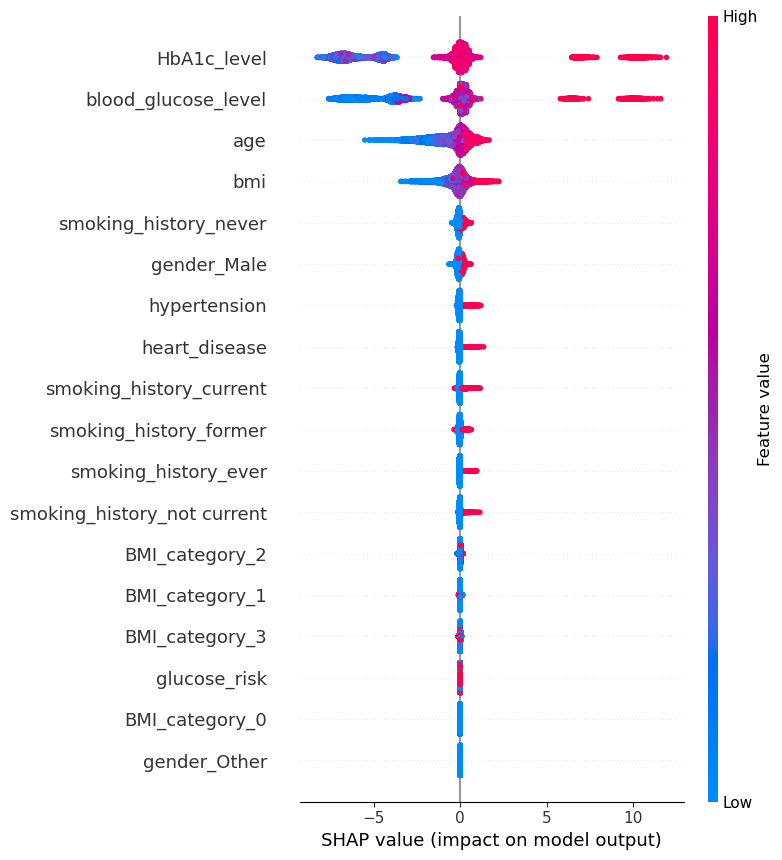

In [14]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [15]:
from sklearn.metrics import roc_auc_score, confusion_matrix

print("ROC-AUC:", roc_auc_score(y_test, preds))
print(confusion_matrix(y_test, preds))

ROC-AUC: 0.8463686094997082
[[17450    59]
 [  523  1198]]


In [17]:
def health_score(glucose, bmi):
    score = 100
    
    if glucose > 140:
        score -= 30
    if bmi > 30:
        score -= 20
        
    return score